<a href="https://colab.research.google.com/github/Vanshika10k/CoffeeCafe/blob/main/PRAC1_MV_56.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile
import os

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/LOL")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [4]:
def enhance_night_image(image):

    # Noise Removal
    denoised = cv2.medianBlur(image, 5)
    denoised = cv2.bilateralFilter(denoised, 9, 75, 75)

    # Gamma Correction
    gamma = 0.5

    table = np.array([
        ((i / 255.0) ** gamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    bright = cv2.LUT(denoised, table)

    # CLAHE Histogram Equalization
    lab = cv2.cvtColor(bright, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=3.0,
        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    enhanced_lab = cv2.merge((cl, a, b))

    enhanced = cv2.cvtColor(
        enhanced_lab,
        cv2.COLOR_LAB2BGR
    )

    # Sharpening
    blur = cv2.GaussianBlur(
        enhanced,
        (0,0),
        sigmaX=3
    )

    sharpened = cv2.addWeighted(
        enhanced,
        1.5,
        blur,
        -0.5,
        0
    )

    return sharpened

In [5]:
for root, dirs, files in os.walk("/content/LOL"):
    print(root)

/content/LOL
/content/LOL/lol_dataset
/content/LOL/lol_dataset/our485
/content/LOL/lol_dataset/our485/high
/content/LOL/lol_dataset/our485/low
/content/LOL/lol_dataset/eval15
/content/LOL/lol_dataset/eval15/high
/content/LOL/lol_dataset/eval15/low


In [6]:
image_paths = glob.glob(
    "/content/LOL/**/*.png",
    recursive=True
)

print("Images Found:", len(image_paths))

Images Found: 1000


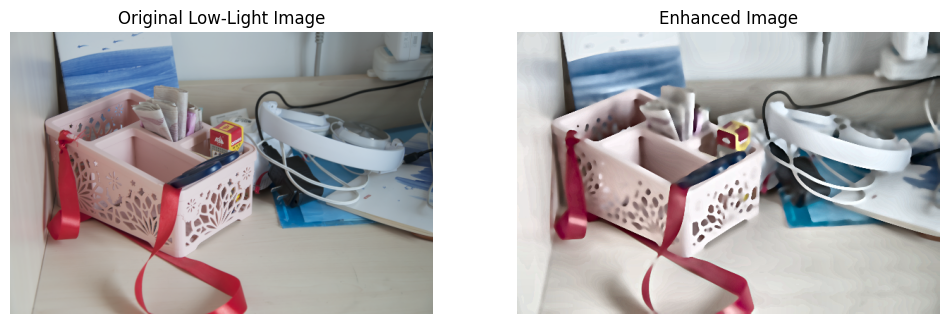

In [7]:
img_path = image_paths[0]

img = cv2.imread(img_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

enhanced = enhance_night_image(img)

enhanced_rgb = cv2.cvtColor(
    enhanced,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Low-Light Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(enhanced_rgb)
plt.title("Enhanced Image")
plt.axis("off")

plt.show()

In [8]:
output_dir = "/content/Enhanced_Images"
os.makedirs(output_dir, exist_ok=True)

image_paths = glob.glob(
    "/content/LOL/**/*.png",
    recursive=True
)

for path in image_paths:

    img = cv2.imread(path)

    if img is None:
        continue

    enhanced = enhance_night_image(img)

    filename = os.path.basename(path)

    save_path = os.path.join(
        output_dir,
        filename
    )

    cv2.imwrite(save_path, enhanced)

print("All Images Enhanced Successfully")

All Images Enhanced Successfully


In [9]:
import shutil

shutil.make_archive(
    "/content/Enhanced_CCTV",
    'zip',
    output_dir
)

'/content/Enhanced_CCTV.zip'